In [1]:
from escripts import eMCMC
from escripts import edata
import importlib
from escripts import eplots

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/inputs.py:22: SyntaxWarning: invalid escape sequence '\d'
  """


In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [57]:
params = eMCMC.build_param_data({'sig':{'fit': False, 'value':0.3}, 'dsigdlogM': {'fit': False, 'value':0}, 
                                 'dsigdz': {'fit': False, 'value':0}
                                })

In [58]:
my_UVLF = eMCMC.UVLF(sorted_data, params, minsig = 0)

In [59]:
my_UVLF.run_MCMC()

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][self.notfit])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][self.notfit]
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


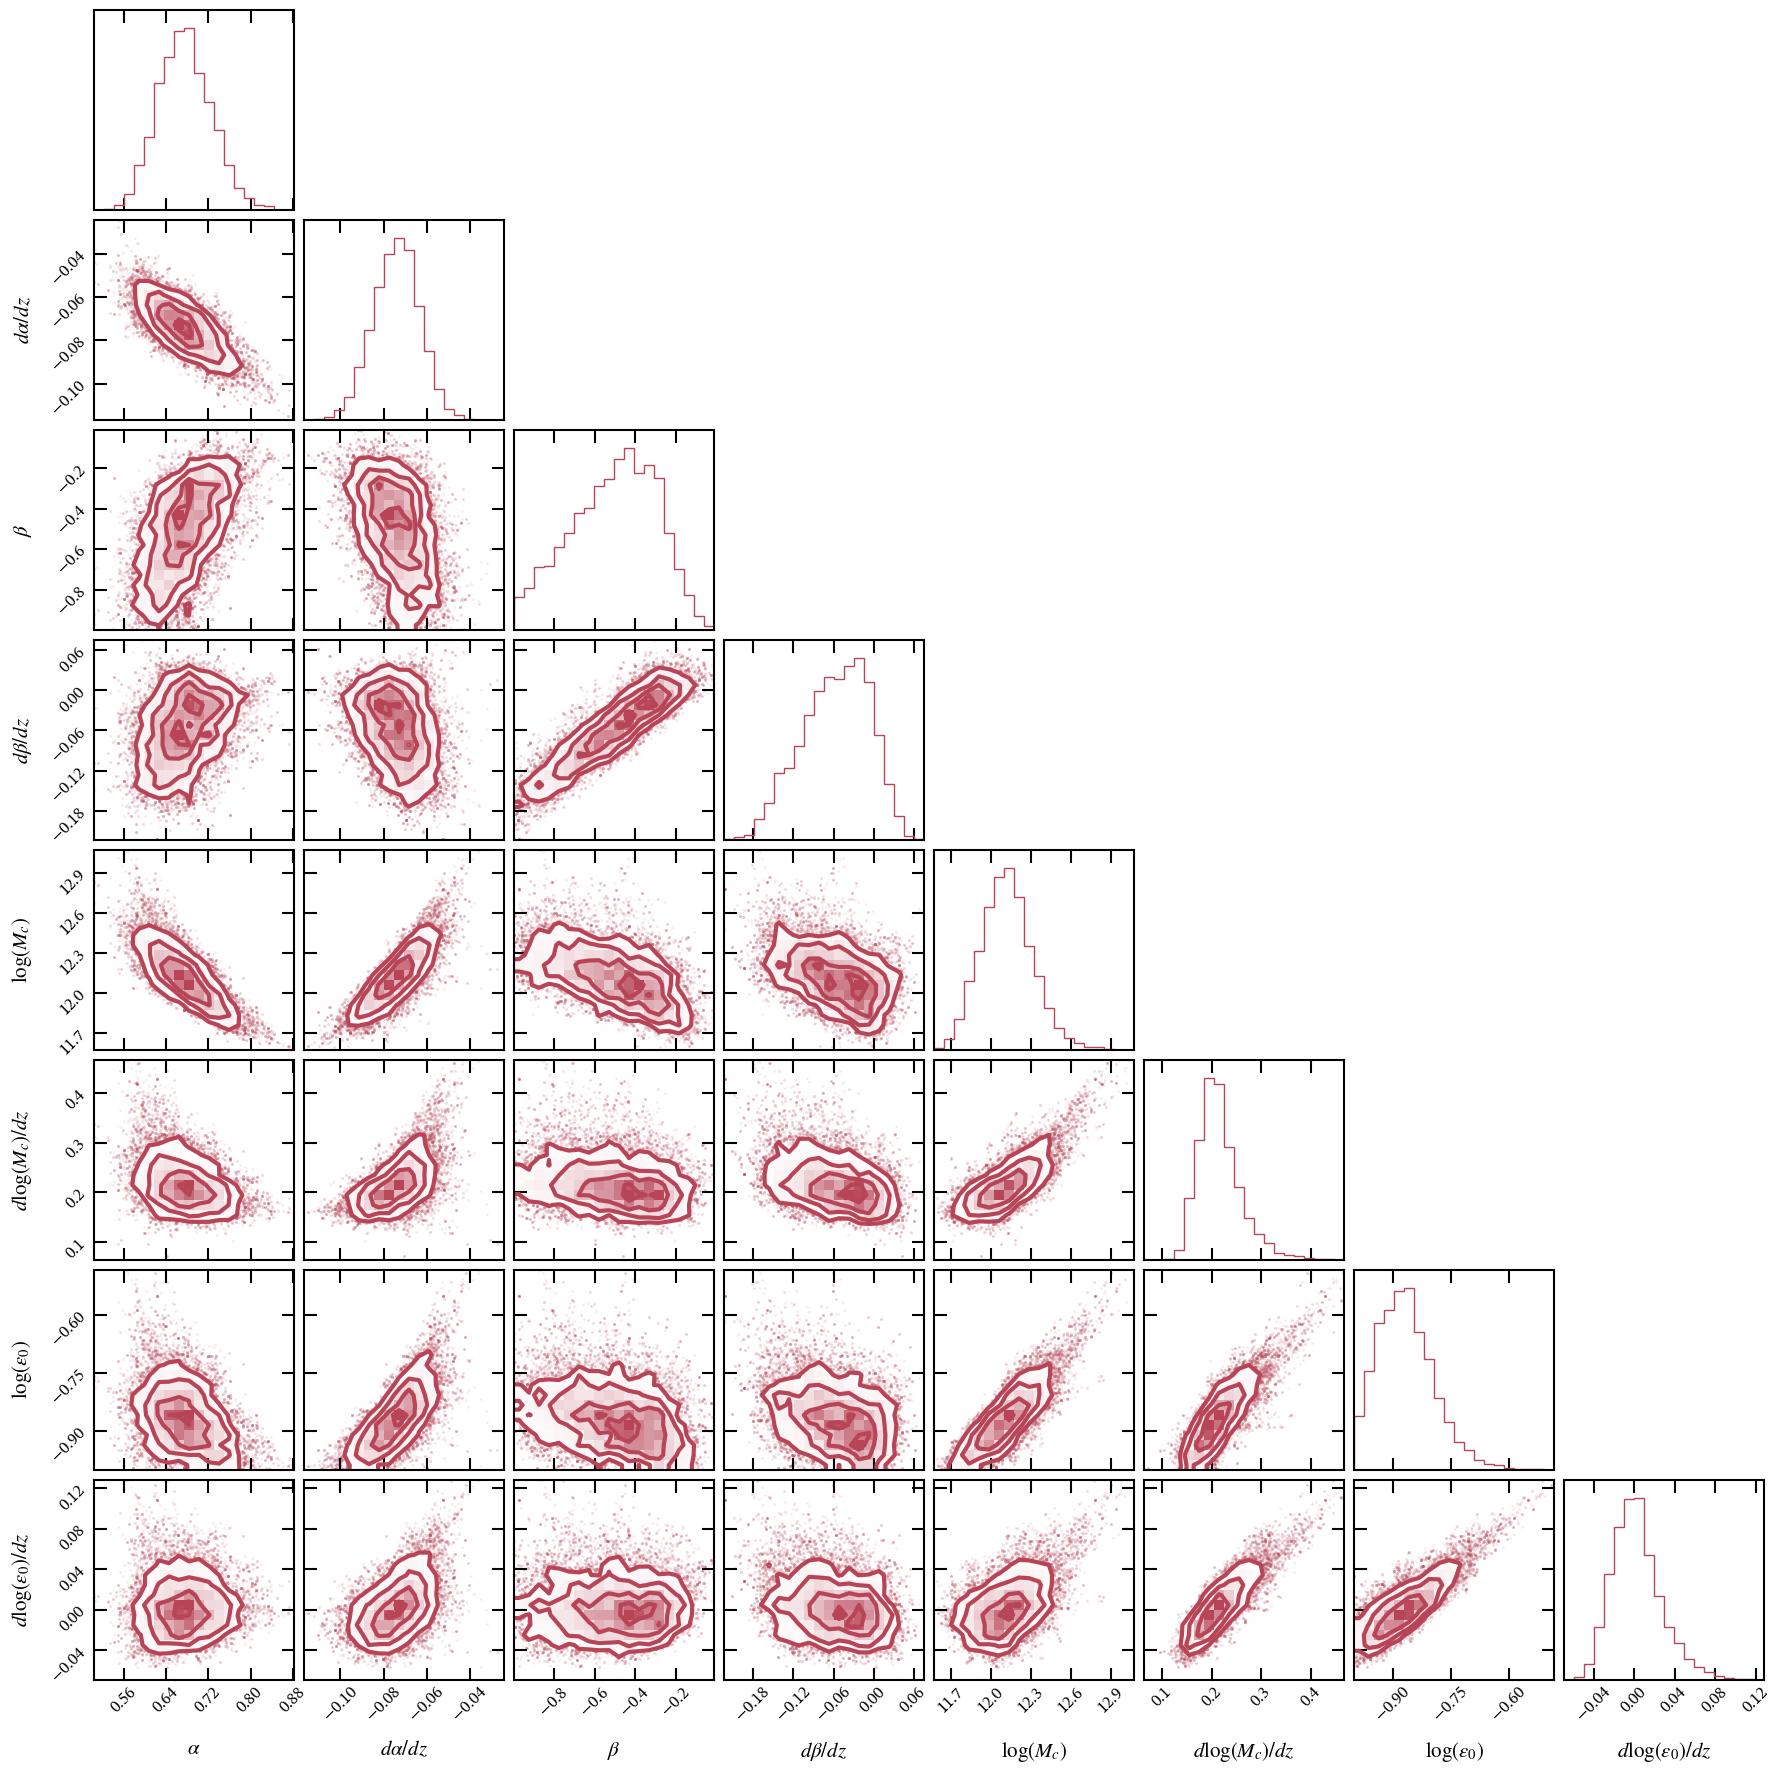

In [60]:
corner_plot = eplots.ecorner(my_UVLF)

In [61]:
samples, best_fit, labels = my_UVLF.get_fit()

In [62]:
eMCMC.get_default_df()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][self.notfit])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][self.notfit]


Skipping $z=4.0$
Skipping $z=5.0$
Skipping $z=6.0$
Skipping $z=7.0$
Skipping $z=9.0$
Skipping $z=10.0$
Skipping $z=11.0$
Skipping $z=12.5$
Skipping $z=13.5$
Skipping $z=14.5$


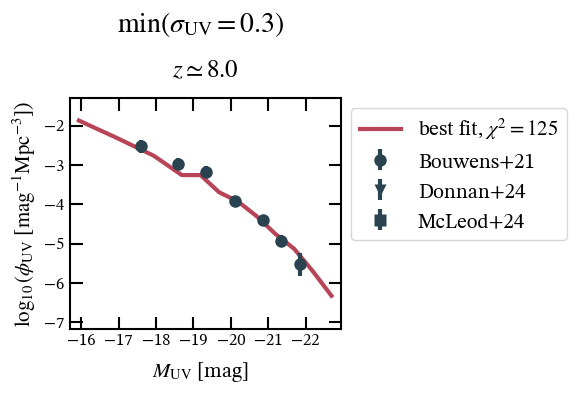

In [64]:
fig = eplots.evolving_UVLF_fit(my_UVLF, nsamples = 0, title = r'$\min(\sigma_{\rm{UV}} = 0.3)$', z_plot=[8])

In [65]:
fig.savefig('/Users/eb35267/Desktop/code/figures/min_sig_good.png')